# IBM Fraud Dataset — Exploratory Data Analysis

EDA tailored to the IBM credit-card fraud dataset and the graph-topology experiments in the paper.

Update `IBM_DATA_PATH` if your data is stored somewhere else.

In [4]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (9, 5)

def display_basic_overview(df, target_col=None):
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nData types:")
    display(df.dtypes.to_frame("dtype"))
    print("\nPreview:")
    display(df.head())
    if target_col and target_col in df.columns:
        print("\nTarget distribution:")
        display(df[target_col].value_counts(dropna=False).to_frame("count"))
        print("Fraud rate:", df[target_col].mean())

def missing_value_table(df):
    out = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100,
        "n_unique": df.nunique(dropna=True),
        "dtype": df.dtypes.astype(str)
    }).sort_values("missing_percent", ascending=False)
    return out

def plot_count(series, title, xlabel="", top_n=None, normalize=False):
    counts = series.value_counts(dropna=False, normalize=normalize)
    if top_n:
        counts = counts.head(top_n)
    ax = counts.plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Proportion" if normalize else "Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_hist(series, title, xlabel="", bins=50, log_x=False):
    x = pd.to_numeric(series, errors="coerce").dropna()
    if log_x:
        x = np.log1p(x[x >= 0])
        xlabel = "log1p(" + xlabel + ")"
    plt.figure()
    plt.hist(x, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def fraud_rate_by(df, col, target_col, min_count=20, top_n=20):
    tmp = (
        df.groupby(col, dropna=False)[target_col]
          .agg(["count", "sum", "mean"])
          .rename(columns={"sum": "fraud_count", "mean": "fraud_rate"})
          .sort_values(["fraud_rate", "count"], ascending=[False, False])
    )
    tmp = tmp[tmp["count"] >= min_count]
    return tmp.head(top_n)

def plot_fraud_rate_by(df, col, target_col, min_count=20, top_n=20, title=None):
    tmp = fraud_rate_by(df, col, target_col, min_count=min_count, top_n=top_n)
    if tmp.empty:
        print(f"No groups in {col} with at least {min_count} records.")
        return tmp
    ax = tmp["fraud_rate"].sort_values().plot(kind="barh")
    ax.set_title(title or f"Fraud rate by {col}")
    ax.set_xlabel("Fraud rate")
    plt.tight_layout()
    plt.show()
    display(tmp)
    return tmp

def temporal_edges_stats(df, group_col, k=1, max_group_size=None):
    if group_col not in df.columns:
        return None
    sizes = df.groupby(group_col).size()
    if max_group_size:
        sizes = sizes.clip(upper=max_group_size)
    edge_est = int(sum(max(0, int(n) - 1) * k for n in sizes))
    n_nodes = len(df)
    avg_degree_est = (2 * edge_est / n_nodes) if n_nodes else 0
    density_est = (2 * edge_est / (n_nodes * (n_nodes - 1))) if n_nodes > 1 else 0
    return {
        "relation": group_col,
        "groups": int(sizes.shape[0]),
        "median_group_size": float(sizes.median()),
        "mean_group_size": float(sizes.mean()),
        "max_group_size": int(sizes.max()),
        "estimated_undirected_edges": edge_est,
        "estimated_avg_degree": avg_degree_est,
        "estimated_density": density_est,
    }

def display_relation_diagnostics(df, relation_cols, k_map=None):
    rows = []
    for col in relation_cols:
        k = 1 if k_map is None else k_map.get(col, 1)
        stats = temporal_edges_stats(df, col, k=k)
        if stats:
            rows.append(stats)
    out = pd.DataFrame(rows)
    display(out)
    return out

In [5]:
import pandas as pd



sample = df.sample(
    n=min(10000, len(df)),
    random_state=42
)

In [6]:
df = pd.read_csv("/Users/royaamiri/Desktop/reduced_dataset.csv")


df.columns = [c.strip() for c in df.columns]

TARGET_COL = "Is Fraud?"
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip().str.lower().map({
    "yes": 1, "no": 0, "true": 1, "false": 0, "1": 1, "0": 0
}).fillna(df[TARGET_COL]).astype(int)

display_basic_overview(df, TARGET_COL)

Shape: (24386834, 15)

Columns:
['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Errors?', 'Is Fraud?']

Data types:


,dtype
User,int64
Card,int64
Year,int64
Month,int64
Day,int64
Time,object
Amount,object
Use Chip,object
Merchant Name,int64
Merchant City,object



Preview:


,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,835,3,2008,11,27,11:41,$51.55,Swipe Transaction,2027553650310142703,Bronx,NY,10456.0,5541,"Insufficient Balance,",0
1,1596,0,2018,2,12,11:09,$9.36,Chip Transaction,-4500542936415012428,Gastonia,NC,28056.0,5814,NaN,0
2,654,0,2017,3,11,15:17,$691.10,Chip Transaction,1913477460590765860,Vancouver,WA,98661.0,5300,NaN,0
3,1597,2,2017,9,17,06:13,$24.11,Chip Transaction,97032797689821735,Marysville,WA,98271.0,5411,NaN,0
4,151,0,2005,11,8,12:48,$37.60,Swipe Transaction,1799189980464955940,Tucson,AZ,85749.0,5499,NaN,0



Target distribution:


,count
Is Fraud?,
0,24357077
1,29757


Fraud rate: 0.001220207592342655


## 1. Data quality

In [7]:
quality = missing_value_table(df)
display(quality)
print("Duplicate rows:", df.duplicated().sum())

,missing_count,missing_percent,n_unique,dtype
Errors?,23998449,98.407399,23,object
Zip,2878135,11.802003,27321,float64
Merchant State,2720821,11.156926,223,object
User,0,0.000000,2000,int64
Card,0,0.000000,9,int64
Year,0,0.000000,30,int64
Month,0,0.000000,12,int64
Day,0,0.000000,31,int64
Time,0,0.000000,1440,object
Amount,0,0.000000,98953,object


Duplicate rows: 0


## 2. Class imbalance

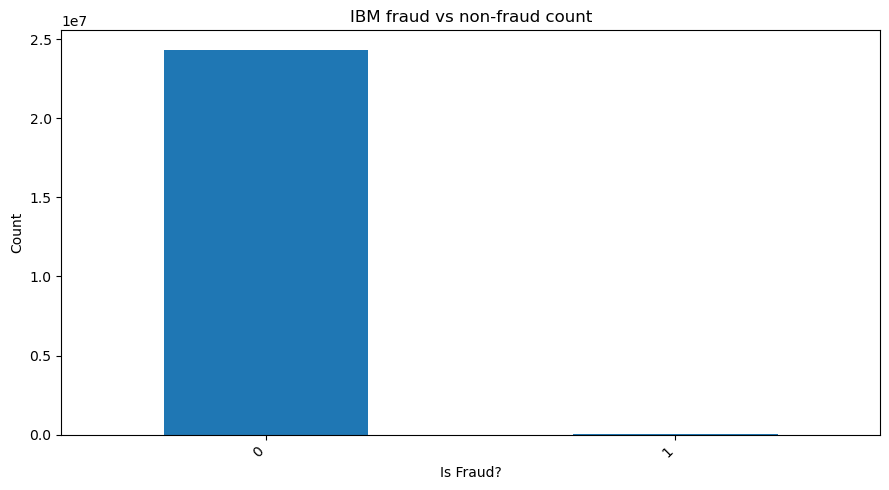

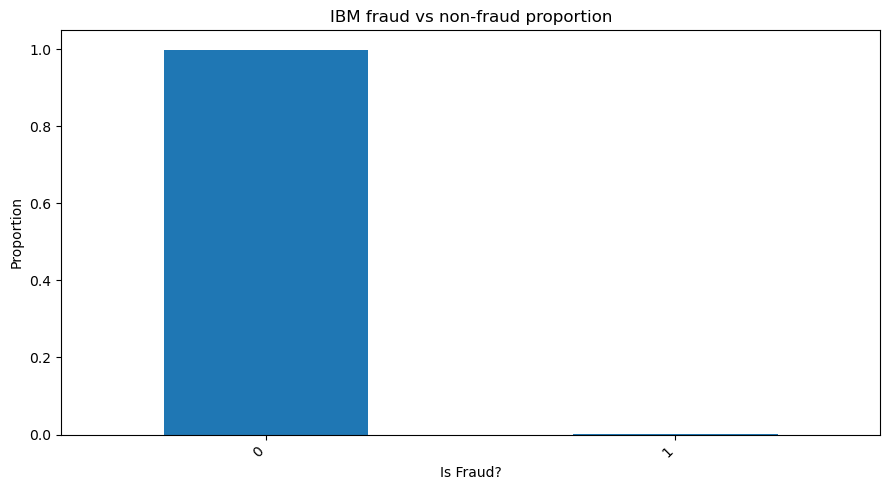

Fraud rate: 0.001220 (0.1220%)


In [8]:
plot_count(df[TARGET_COL], "IBM fraud vs non-fraud count", xlabel=TARGET_COL)
plot_count(df[TARGET_COL], "IBM fraud vs non-fraud proportion", xlabel=TARGET_COL, normalize=True)
fraud_rate = df[TARGET_COL].mean()
print(f"Fraud rate: {fraud_rate:.6f} ({fraud_rate*100:.4f}%)")

## 3. Amount analysis

,Amount
count,2.438683e+07
mean,4.363393e+01
std,8.202244e+01
min,-5.000000e+02
25%,9.200000e+00
50%,3.014000e+01
75%,6.506000e+01
max,1.239050e+04


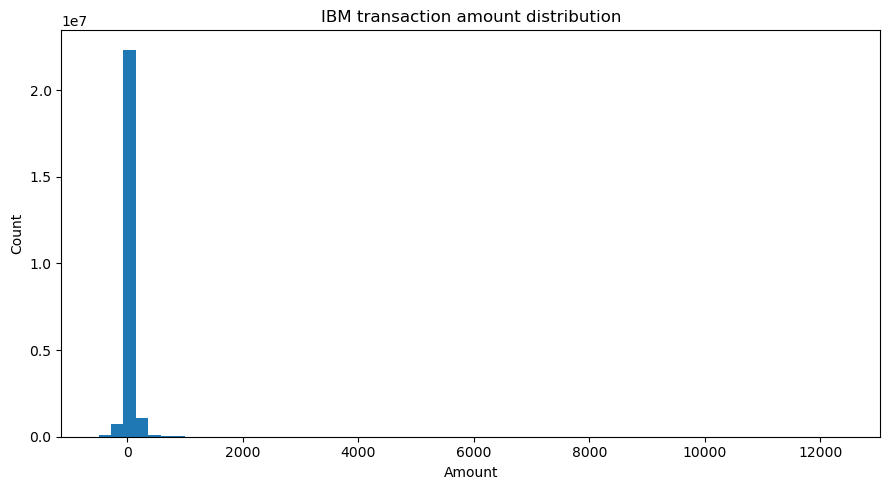

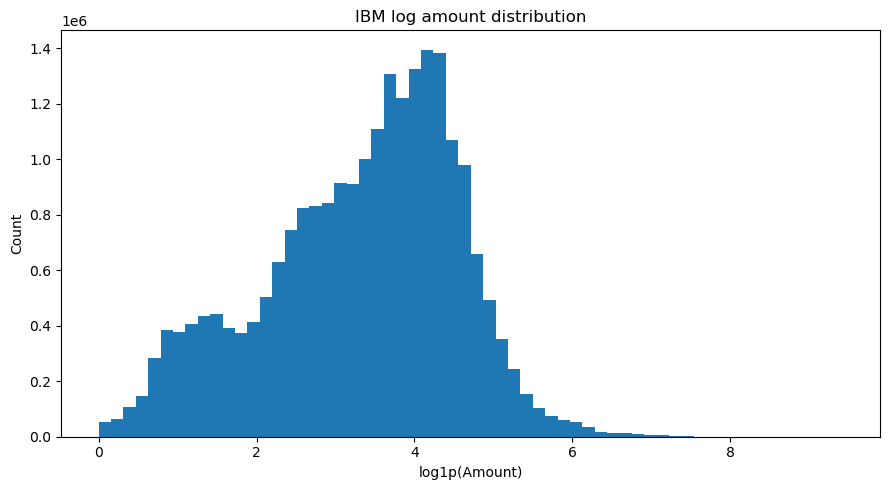

,count,mean,std,min,25%,50%,75%,max
Is Fraud?,,,,,,,,
0,24357077.0,43.554576,81.739217,-500.0,9.20,30.11,65.00,12390.50
1,29757.0,108.590874,201.167421,-500.0,18.36,71.02,150.13,5694.44


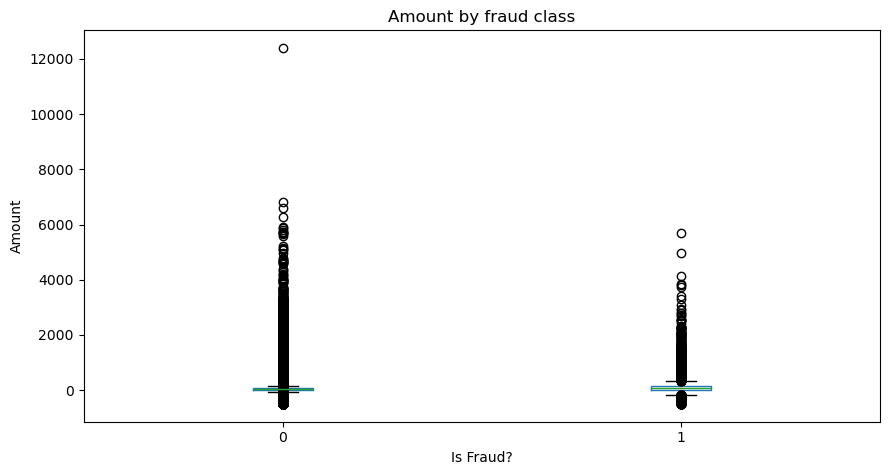

In [9]:
df["Amount_clean"] = pd.to_numeric(
    df["Amount"].astype(str).str.replace(r"[£$€,]", "", regex=True).str.strip(),
    errors="coerce"
)

display(df["Amount_clean"].describe().to_frame("Amount"))
plot_hist(df["Amount_clean"], "IBM transaction amount distribution", xlabel="Amount", bins=60)
plot_hist(df["Amount_clean"], "IBM log amount distribution", xlabel="Amount", bins=60, log_x=True)
display(df.groupby(TARGET_COL)["Amount_clean"].describe())

df.boxplot(column="Amount_clean", by=TARGET_COL, grid=False)
plt.title("Amount by fraud class")
plt.suptitle("")
plt.xlabel("Is Fraud?")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

## 4. Temporal analysis

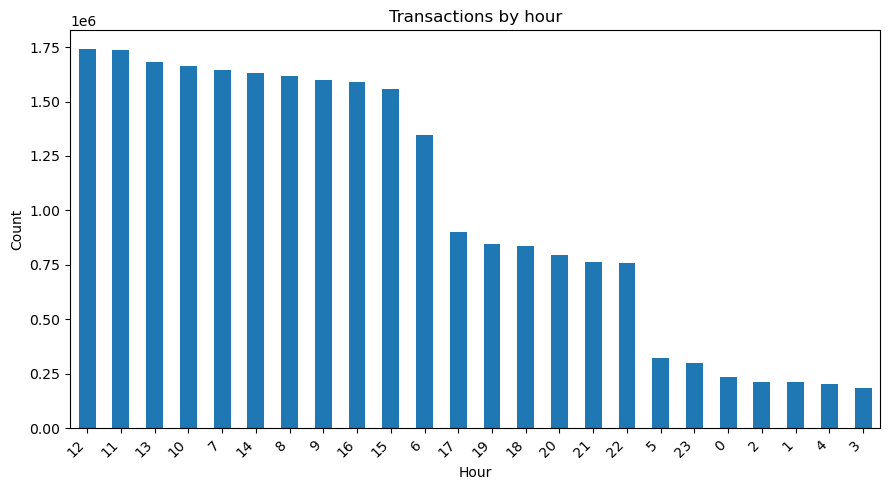

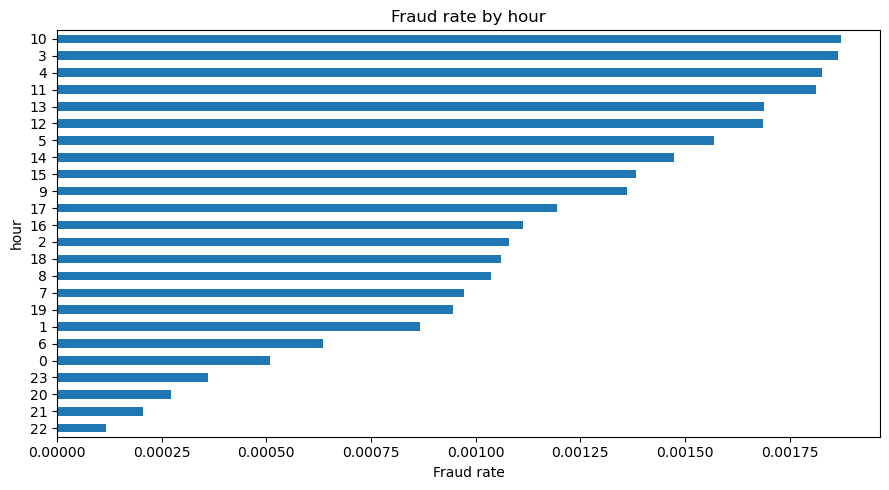

,count,fraud_count,fraud_rate
hour,,,
10,1664496,3116,0.001872
3,183370,342,0.001865
4,203548,372,0.001828
11,1736005,3146,0.001812
13,1681231,2837,0.001687
12,1739863,2933,0.001686
5,321586,505,0.001570
14,1632850,2408,0.001475
15,1559095,2155,0.001382


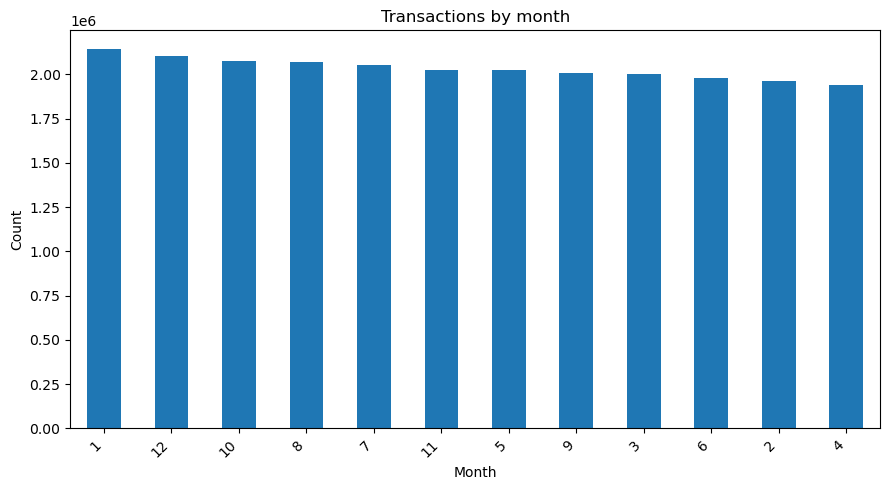

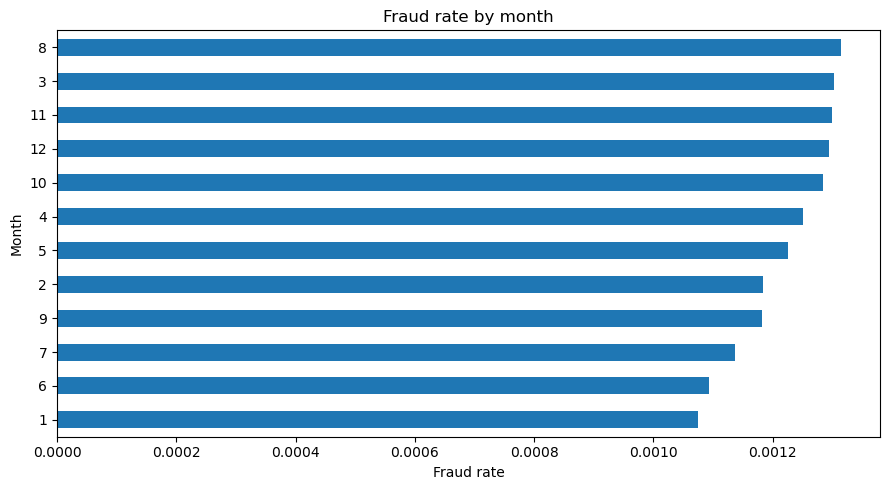

,count,fraud_count,fraud_rate
Month,,,
8,2070399,2721,0.001314
3,2002860,2608,0.001302
11,2026823,2635,0.001300
12,2104426,2723,0.001294
10,2075183,2666,0.001285
4,1941799,2430,0.001251
5,2023407,2481,0.001226
2,1960408,2320,0.001183
9,2006305,2373,0.001183


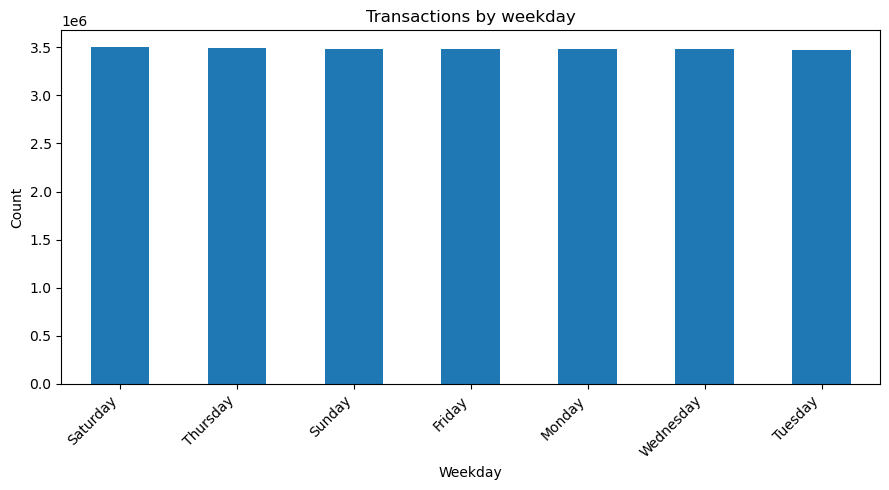

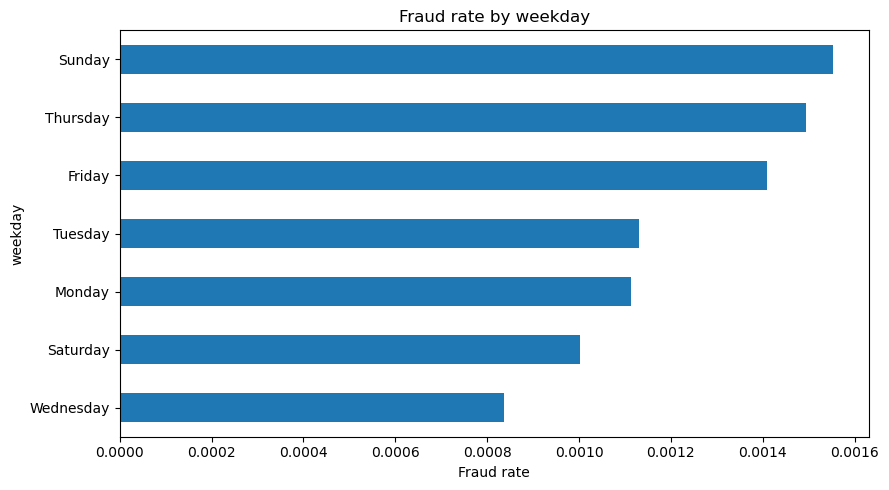

,count,fraud_count,fraud_rate
weekday,,,
Sunday,3485188,5415,0.001554
Thursday,3494998,5220,0.001494
Friday,3482887,4908,0.001409
Tuesday,3468161,3921,0.001131
Monday,3480255,3876,0.001114
Saturday,3499585,3506,0.001002
Wednesday,3475760,2911,0.000838


In [10]:
time_parsed = pd.to_datetime(df["Time"], format="%H:%M", errors="coerce")
df["hour"] = time_parsed.dt.hour
df["minute"] = time_parsed.dt.minute

if all(c in df.columns for c in ["Year", "Month", "Day"]):
    date_str = (
        df["Year"].astype(str).str.zfill(4) + "-" +
        df["Month"].astype(str).str.zfill(2) + "-" +
        df["Day"].astype(str).str.zfill(2)
    )
    df["transaction_date"] = pd.to_datetime(date_str, errors="coerce")
    df["weekday"] = df["transaction_date"].dt.day_name()

plot_count(df["hour"], "Transactions by hour", xlabel="Hour")
plot_fraud_rate_by(df, "hour", TARGET_COL, min_count=10, top_n=24, title="Fraud rate by hour")

if "Month" in df.columns:
    plot_count(df["Month"], "Transactions by month", xlabel="Month")
    plot_fraud_rate_by(df, "Month", TARGET_COL, min_count=10, top_n=12, title="Fraud rate by month")

if "weekday" in df.columns:
    plot_count(df["weekday"], "Transactions by weekday", xlabel="Weekday")
    plot_fraud_rate_by(df, "weekday", TARGET_COL, min_count=10, top_n=7, title="Fraud rate by weekday")

## 5. User and cardholder behaviour

,transactions_per_User
count,2000.000000
mean,12193.417000
std,10719.992736
min,15.000000
25%,4008.000000
50%,10860.500000
75%,17425.750000
max,82355.000000


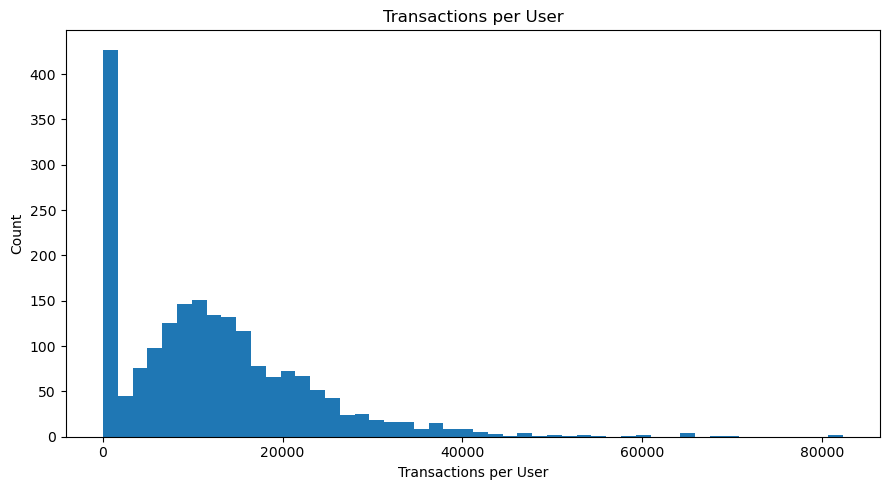

,count,fraud_count,fraud_rate
User,,,
1731,3622,64,0.017670
608,1440,16,0.011111
744,2182,22,0.010082
945,7534,75,0.009955
1709,10218,86,0.008417
618,2292,19,0.008290
450,4064,33,0.008120
908,6145,49,0.007974
662,3334,26,0.007798


,transactions_per_Card
count,9.000000e+00
mean,2.709648e+06
std,3.164347e+06
min,5.184000e+03
25%,1.767290e+05
50%,1.309117e+06
75%,4.305585e+06
max,8.696391e+06


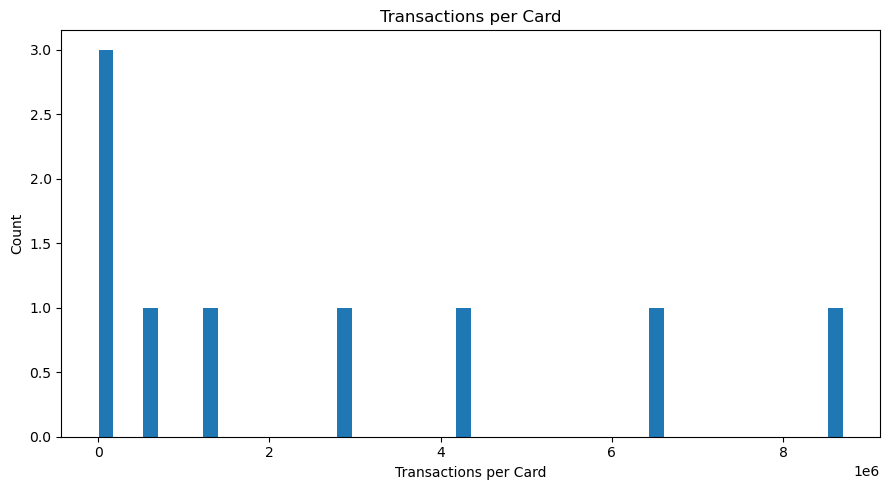

,count,fraud_count,fraud_rate
Card,,,
8,5184,25,0.004823
7,46383,109,0.002350
6,176729,350,0.001980
5,563097,1016,0.001804
4,1309117,2157,0.001648
3,2790773,4135,0.001482
2,4305585,5807,0.001349
1,6493575,7514,0.001157
0,8696391,8644,0.000994


In [11]:
for col in ["User", "Card"]:
    if col in df.columns:
        counts = df[col].value_counts()
        display(counts.describe().to_frame(f"transactions_per_{col}"))
        plot_hist(counts, f"Transactions per {col}", xlabel=f"Transactions per {col}", bins=50)
        display(fraud_rate_by(df, col, TARGET_COL, min_count=2, top_n=20))

## 6. Merchant, MCC, chip, and error analysis


--- Merchant Name ---


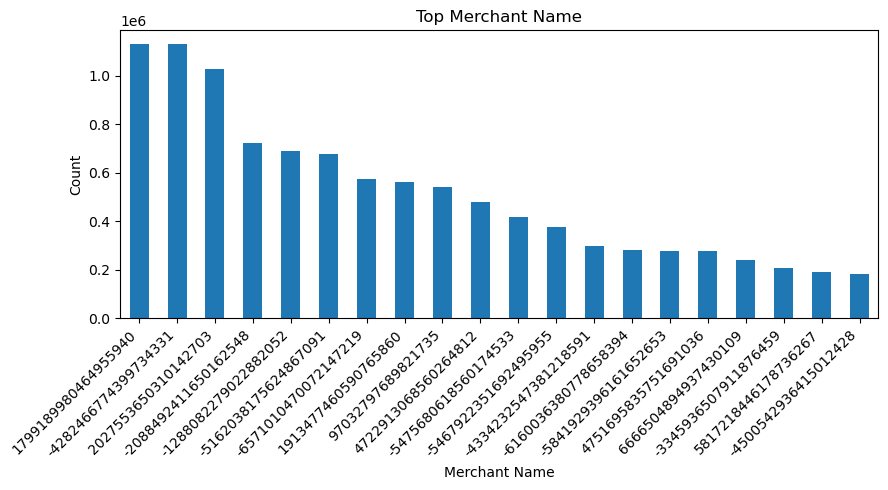

,count,fraud_count,fraud_rate
Merchant Name,,,
-7231389139399574921,148,148,1.0
3897876142681371300,55,55,1.0
-563157518771065152,53,53,1.0
-5674292871952204677,36,36,1.0
860447638725616284,34,34,1.0
-8291617834869479558,19,19,1.0
938055602653740367,18,18,1.0
-9009228730649086683,16,16,1.0
6266551787501921294,15,15,1.0



--- Merchant City ---


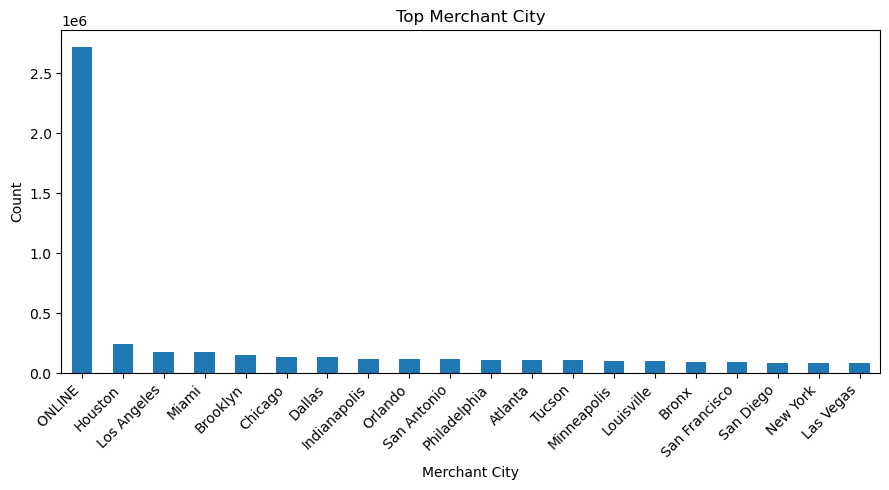

,count,fraud_count,fraud_rate
Merchant City,,,
Funafuti,59,59,1.000000
Algiers,654,629,0.961774
Green Springs,21,18,0.857143
Port au Prince,446,375,0.840807
Suva,40,32,0.800000
Abuja,233,143,0.613734
Berlin Heights,12,7,0.583333
Mcconnell Afb,9,5,0.555556
Istanbul,472,257,0.544492



--- Merchant State ---


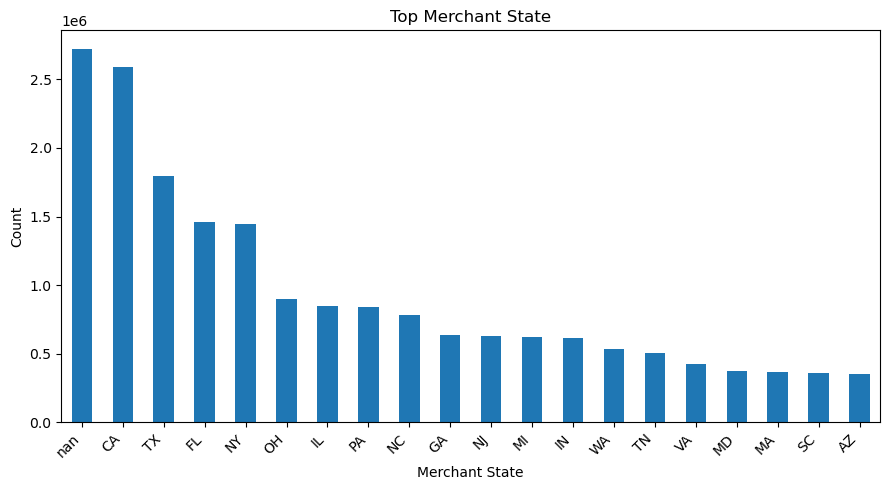

,count,fraud_count,fraud_rate
Merchant State,,,
Tuvalu,59,59,1.000000
Algeria,654,629,0.961774
Haiti,446,375,0.840807
Fiji,40,32,0.800000
Nigeria,233,143,0.613734
Turkey,472,257,0.544492
Italy,8730,4682,0.536312
Japan,3955,49,0.012389
NaN,2720821,18349,0.006744



--- MCC ---


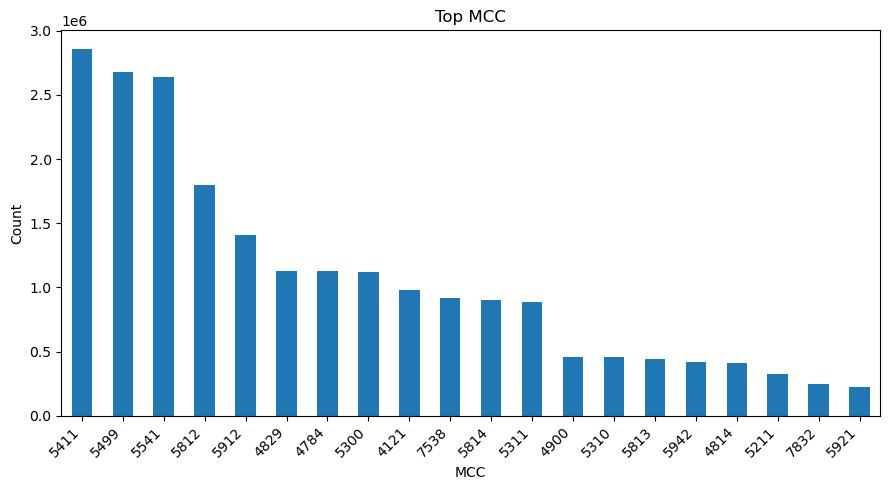

,count,fraud_count,fraud_rate
MCC,,,
4411,634,317,0.500000
5733,496,127,0.256048
5045,5013,470,0.093756
3006,702,59,0.084046
3144,632,53,0.083861
3008,714,50,0.070028
5732,12593,843,0.066942
3007,666,41,0.061562
3075,666,40,0.060060



--- Use Chip ---


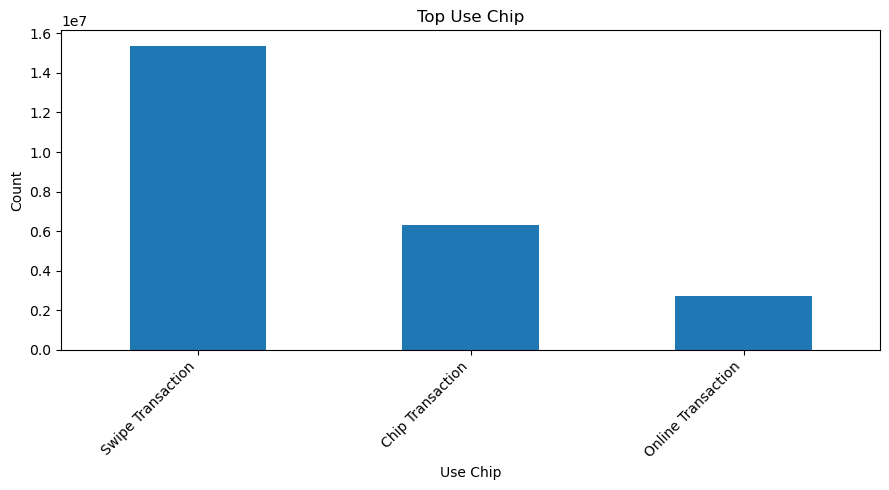

,count,fraud_count,fraud_rate
Use Chip,,,
Online Transaction,2713220,18349,0.006763
Chip Transaction,6287584,4836,0.000769
Swipe Transaction,15386030,6572,0.000427



--- Errors? ---


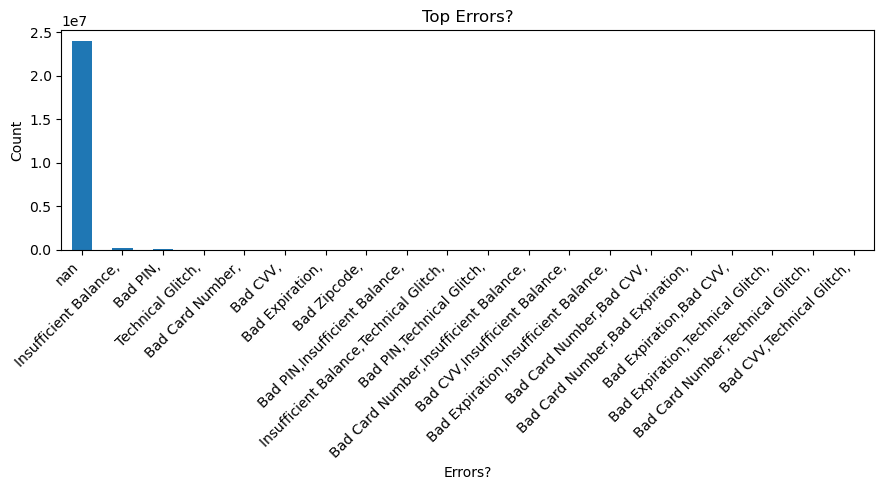

,count,fraud_count,fraud_rate
Errors?,,,
"Bad Expiration,Technical Glitch,",32,2,0.062500
"Bad CVV,Technical Glitch,",21,1,0.047619
"Bad CVV,Insufficient Balance,",89,4,0.044944
"Bad Expiration,Bad CVV,",47,2,0.042553
"Bad CVV,",10740,280,0.026071
"Bad Card Number,Insufficient Balance,",122,2,0.016393
"Bad Expiration,Insufficient Balance,",78,1,0.012821
"Bad PIN,Insufficient Balance,",581,7,0.012048
"Bad Expiration,",10716,120,0.011198


In [12]:
for col in ["Merchant Name", "Merchant City", "Merchant State", "MCC", "Use Chip", "Errors?"]:
    if col in df.columns:
        print(f"\n--- {col} ---")
        plot_count(df[col], f"Top {col}", xlabel=col, top_n=20)
        display(fraud_rate_by(df, col, TARGET_COL, min_count=5, top_n=20))

## 7. Graph-topology diagnostics

The IBM pipeline builds temporal relation graphs over `Card`, `User`, `Merchant Name`, and `MCC`.

,relation,groups,median_group_size,mean_group_size,max_group_size,estimated_undirected_edges,estimated_avg_degree,estimated_density
0,Card,9,1309117.0,2.709648e+06,8696391,24386825,1.999999,8.201144e-08
1,User,2000,10860.5,1.219342e+04,82355,24384834,1.999836,8.200474e-08
2,Merchant Name,100343,4.0,2.430347e+02,1130225,24286491,1.991771,8.167402e-08
3,MCC,109,26316.0,2.237324e+05,2860737,24386725,1.999991,8.201110e-08



Card: 9 groups


,Card_group_size
count,9.000000e+00
mean,2.709648e+06
std,3.164347e+06
min,5.184000e+03
25%,1.767290e+05
50%,1.309117e+06
75%,4.305585e+06
max,8.696391e+06


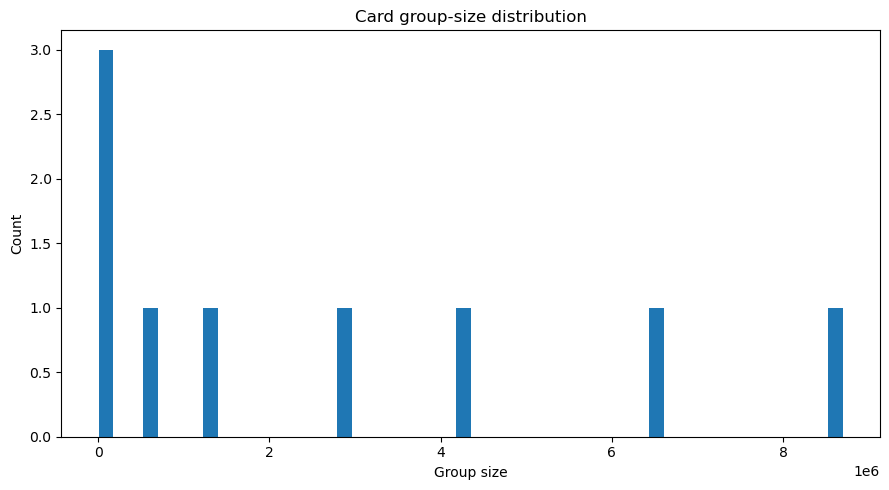


User: 2000 groups


,User_group_size
count,2000.000000
mean,12193.417000
std,10719.992736
min,15.000000
25%,4008.000000
50%,10860.500000
75%,17425.750000
max,82355.000000


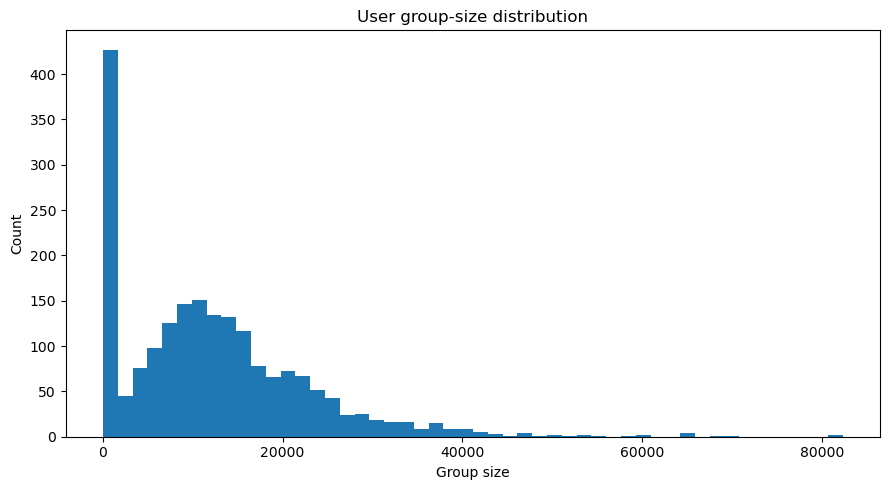


Merchant Name: 100343 groups


,Merchant Name_group_size
count,1.003430e+05
mean,2.430347e+02
std,8.687755e+03
min,1.000000e+00
25%,1.000000e+00
50%,4.000000e+00
75%,1.900000e+01
max,1.130225e+06


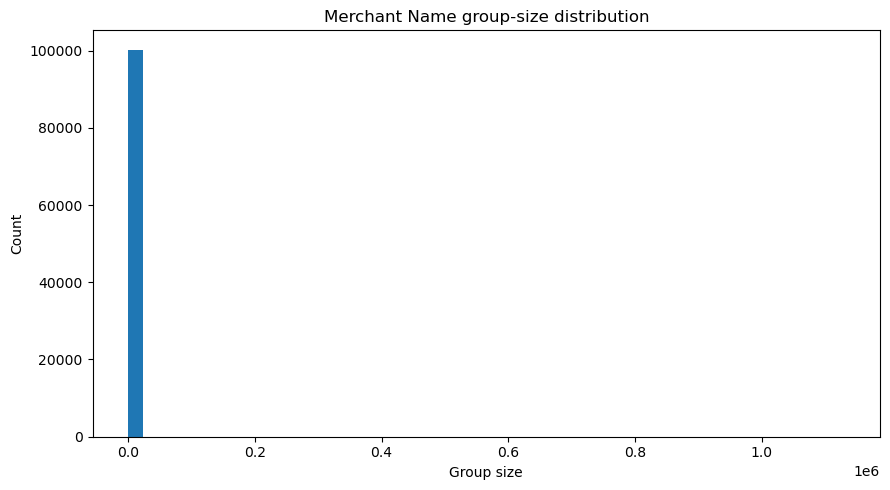


MCC: 109 groups


,MCC_group_size
count,1.090000e+02
mean,2.237324e+05
std,5.334626e+05
min,4.960000e+02
25%,5.866000e+03
50%,2.631600e+04
75%,1.152470e+05
max,2.860737e+06


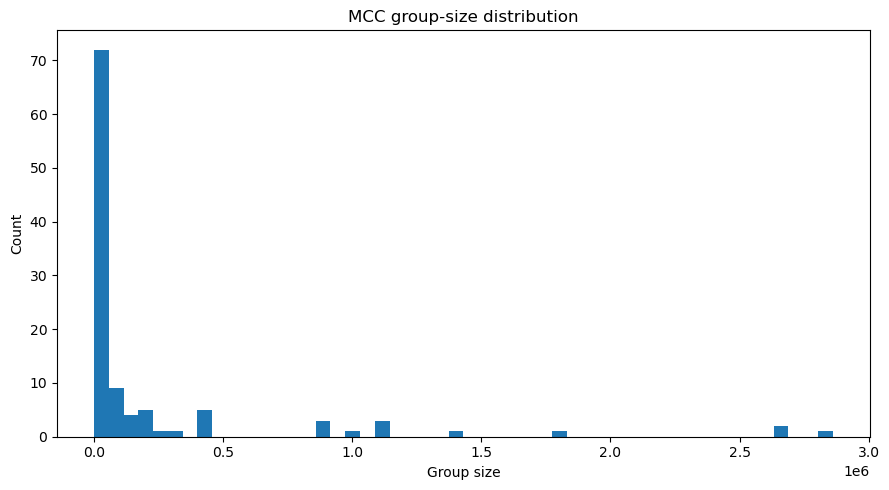

In [13]:
relation_cols = ["Card", "User", "Merchant Name", "MCC"]
ibm_graph_diag = display_relation_diagnostics(df, relation_cols, k_map={
    "Card": 1,
    "User": 1,
    "Merchant Name": 1,
    "MCC": 1,
})

for col in relation_cols:
    if col in df.columns:
        sizes = df.groupby(col).size().sort_values(ascending=False)
        print(f"\n{col}: {sizes.shape[0]} groups")
        display(sizes.describe().to_frame(f"{col}_group_size"))
        plot_hist(sizes, f"{col} group-size distribution", xlabel="Group size", bins=50)

## 8. Key findings

Use this section after running the notebook on the full dataset.

Suggested paper-focused points:

- IBM is highly imbalanced; report the fraud rate clearly.
- Sparse per-card/per-user histories can weaken intra-group graphs.
- Shared merchant and MCC relations may provide cross-cardholder signal for multi-relation topology.
- If similarity edges increase density without improving fraud separation, that supports the hybrid-degradation claim.